In [1]:
# Retail & Marketing Analytics Project
# Part 3: Exploratory Data Analysis (EDA)

"""
Project: Retail & Marketing Analytics - Customer Segmentation & Sales Optimization
Part: 03 - Exploratory Data Analysis (EDA)

Objective:
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Time series analysis
- Customer behavior analysis
- Product performance analysis
- Generate insights
"""

# ============================================================================
# 1. IMPORT LIBRARIES AND LOAD CLEANED DATA
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Load cleaned data
df = pd.read_csv('data/processed/cleaned_retail_sales.csv')

# Convert date columns back to datetime
date_cols = ['Order_Date', 'Ship_Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print("="*80)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Analysis Period: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")

EXPLORATORY DATA ANALYSIS (EDA)

Dataset Shape: (10000, 45)
Analysis Period: 2022-01-01 to 2023-02-21



UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
✓ Saved: 05_numerical_distributions.png


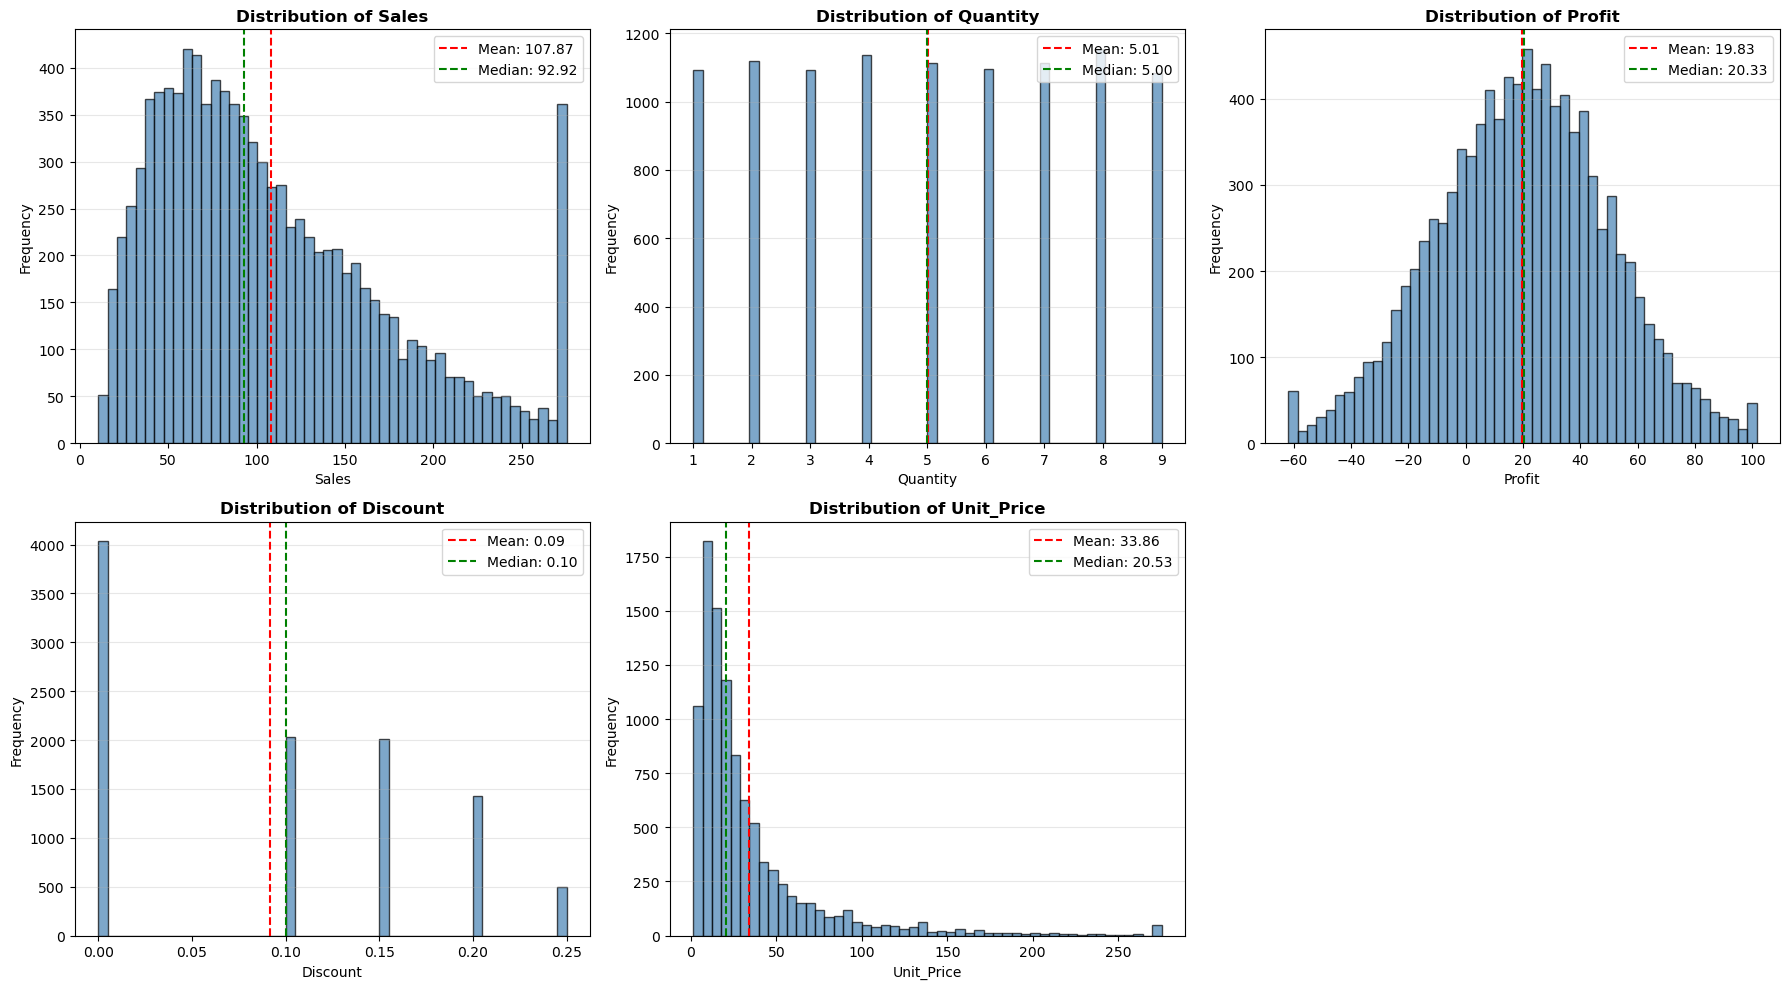


 Statistical Summary:
          Sales  Quantity    Profit  Discount  Unit_Price
count  10000.00  10000.00  10000.00  10000.00    10000.00
mean     107.87      5.01     19.83      0.09       33.86
std       64.55      2.58     30.20      0.08       39.60
min       10.35      1.00    -61.87      0.00        1.36
25%       58.33      3.00     -0.61      0.00       11.11
50%       92.92      5.00     20.33      0.10       20.53
75%      145.13      7.00     40.22      0.15       39.13
max      275.33      9.00    101.47      0.25      275.33

 Skewness and Kurtosis:
Sales           - Skewness:   0.89, Kurtosis:   0.15
Quantity        - Skewness:  -0.01, Kurtosis:  -1.23
Profit          - Skewness:  -0.03, Kurtosis:  -0.13
Discount        - Skewness:   0.19, Kurtosis:  -1.34
Unit_Price      - Skewness:   2.99, Kurtosis:  11.27

UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
✓ Saved: 06_categorical_distributions.png


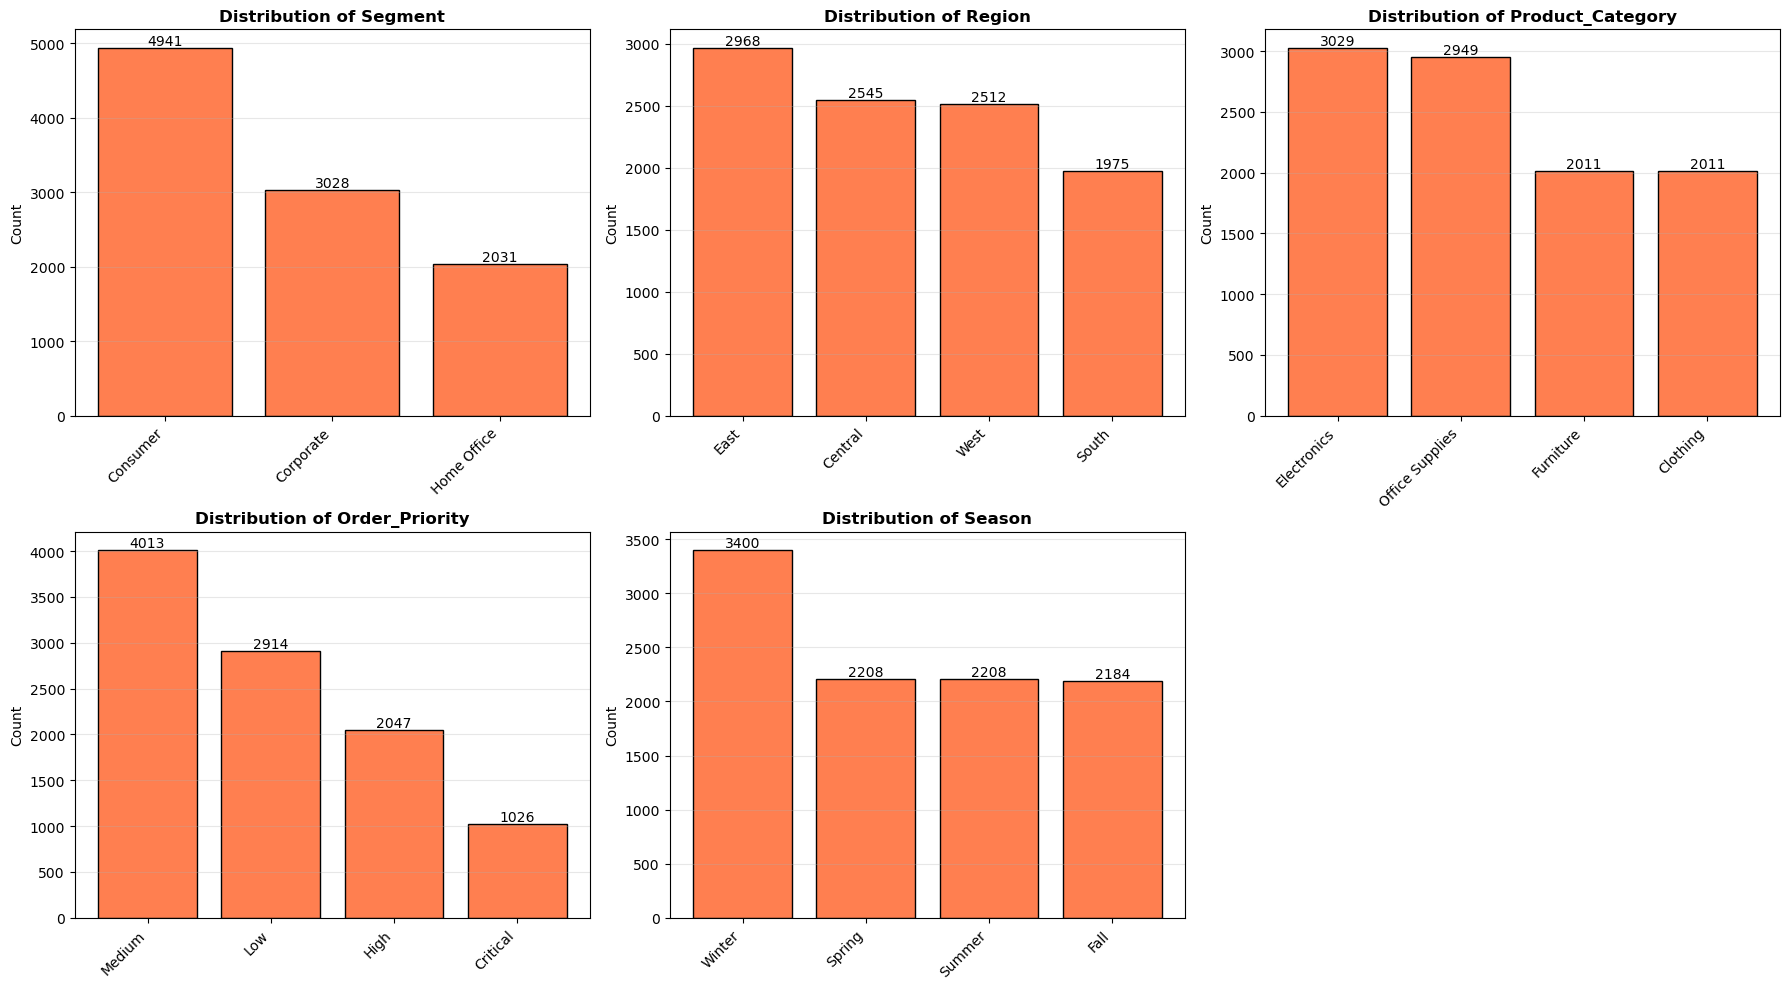


 Categorical Variable Counts:

Segment:
Segment
Consumer       4941
Corporate      3028
Home Office    2031
Name: count, dtype: int64

Region:
Region
East       2968
Central    2545
West       2512
South      1975
Name: count, dtype: int64

Product_Category:
Product_Category
Electronics        3029
Office Supplies    2949
Furniture          2011
Clothing           2011
Name: count, dtype: int64

Order_Priority:
Order_Priority
Medium      4013
Low         2914
High        2047
Critical    1026
Name: count, dtype: int64

Season:
Season
Winter    3400
Spring    2208
Summer    2208
Fall      2184
Name: count, dtype: int64


In [2]:
# ============================================================================
# 2. UNIVARIATE ANALYSIS - NUMERICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - NUMERICAL VARIABLES")
print("="*80)

# Select numerical columns
numerical_cols = ['Sales', 'Quantity', 'Profit', 'Discount', 'Unit_Price']
numerical_cols = [col for col in numerical_cols if col in df.columns]

# Distribution plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        # Histogram with KDE
        axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frequency', fontsize=10)
        axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                         label=f'Mean: {df[col].mean():.2f}')
        axes[idx].axvline(df[col].median(), color='green', linestyle='--', 
                         label=f'Median: {df[col].median():.2f}')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)
        # Remove empty subplots
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('outputs/figures/05_numerical_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 05_numerical_distributions.png")
plt.show()

# Statistical summary
print("\n Statistical Summary:")
print(df[numerical_cols].describe().round(2))

# Skewness and Kurtosis
print("\n Skewness and Kurtosis:")
for col in numerical_cols:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"{col:15s} - Skewness: {skew:6.2f}, Kurtosis: {kurt:6.2f}")

# ============================================================================
# 3. UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES
# ============================================================================

print("\n" + "="*80)
print("UNIVARIATE ANALYSIS - CATEGORICAL VARIABLES")
print("="*80)
# Select categorical columns
categorical_cols = ['Segment', 'Region', 'Product_Category', 'Order_Priority', 'Season']
categorical_cols = [col for col in categorical_cols if col in df.columns]

# Create bar plots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        value_counts = df[col].value_counts()
        axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', edgecolor='black')
        axes[idx].set_xticks(range(len(value_counts)))
        axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold', fontsize=12)
        axes[idx].set_ylabel('Count', fontsize=10)
        axes[idx].grid(axis='y', alpha=0.3)
        
        # Add value labels on bars
        for i, v in enumerate(value_counts.values):
            axes[idx].text(i, v, str(v), ha='center', va='bottom')

# Remove empty subplots
for idx in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('outputs/figures/06_categorical_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 06_categorical_distributions.png")
plt.show()

# Print value counts
print("\n Categorical Variable Counts:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


BIVARIATE ANALYSIS

 Sales by Product Category:
                  Total_Sales  Avg_Sales  Order_Count
Product_Category                                     
Electronics         328422.71     108.43         3029
Office Supplies     321280.86     108.95         2949
Furniture           214958.03     106.89         2011
Clothing            214009.37     106.42         2011
✓ Saved: 07_sales_by_category.html

 Sales by Region:
         Total_Sales  Avg_Sales  Order_Count
Region                                      
East       318581.37     107.34         2968
Central    275688.18     108.33         2545
West       272330.96     108.41         2512
South      212070.47     107.38         1975
✓ Saved: 08_sales_by_region.html

 Sales by Customer Segment:
             Total_Sales  Avg_Sales  Order_Count
Segment                                         
Consumer       537235.41     108.73         4941
Corporate      325499.15     107.50         3028
Home Office    215936.42     106.32         2

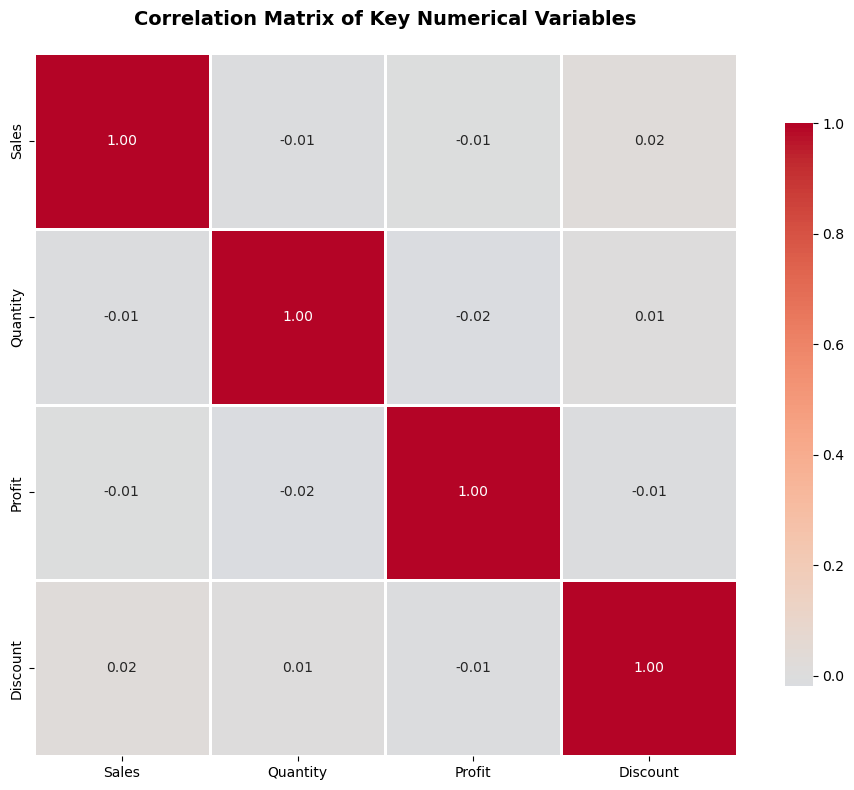


Correlation Coefficients:
             Sales  Quantity    Profit  Discount
Sales     1.000000 -0.010920 -0.005396  0.019058
Quantity -0.010920  1.000000 -0.018266  0.008203
Profit   -0.005396 -0.018266  1.000000 -0.011315
Discount  0.019058  0.008203 -0.011315  1.000000


In [4]:
# ============================================================================
# 4. BIVARIATE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("BIVARIATE ANALYSIS")
print("="*80)

# 4.1 Sales by Category
if 'Product_Category' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Product Category:")
    category_sales = df.groupby('Product_Category')['Sales'].agg(['sum', 'mean', 'count']).round(2)
    category_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    category_sales = category_sales.sort_values('Total_Sales', ascending=False)
    print(category_sales)
    
    # Visualization
    fig = px.bar(category_sales.reset_index(), 
                 x='Product_Category', 
                 y='Total_Sales',
                 title='Total Sales by Product Category',
                 labels={'Total_Sales': 'Total Sales ($)', 'Product_Category': 'Category'},
                 color='Total_Sales',
                 color_continuous_scale='viridis')
    fig.write_html('outputs/figures/07_sales_by_category.html')
    print("✓ Saved: 07_sales_by_category.html")

# 4.2 Sales by Region
if 'Region' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Region:")
    region_sales = df.groupby('Region')['Sales'].agg(['sum', 'mean', 'count']).round(2)
    region_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    region_sales = region_sales.sort_values('Total_Sales', ascending=False)
    print(region_sales)
    
    # Pie chart
    fig = px.pie(region_sales.reset_index(), 
                 values='Total_Sales', 
                 names='Region',
                 title='Revenue Distribution by Region',
                 hole=0.4)
    fig.write_html('outputs/figures/08_sales_by_region.html')
    print("✓ Saved: 08_sales_by_region.html")

# 4.3 Sales by Customer Segment
if 'Segment' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Customer Segment:")
    segment_sales = df.groupby('Segment')['Sales'].agg(['sum', 'mean', 'count']).round(2)
    segment_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    print(segment_sales)

# 4.4 Correlation Analysis
print("\n Correlation Analysis:")
numerical_for_corr = ['Sales', 'Quantity', 'Profit', 'Discount']
numerical_for_corr = [col for col in numerical_for_corr if col in df.columns]

correlation_matrix = df[numerical_for_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Key Numerical Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/09_correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: 09_correlation_matrix.png")
plt.show()

print("\nCorrelation Coefficients:")
print(correlation_matrix)

In [6]:
# ============================================================================
# 5. TIME SERIES ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("TIME SERIES ANALYSIS")
print("="*80)

# 5.1 Monthly Sales Trend
if 'Order_Date' in df.columns and 'Sales' in df.columns:
    print("\n Monthly Sales Trend:")
    df['YearMonth'] = df['Order_Date'].dt.to_period('M')
    monthly_sales = df.groupby('YearMonth')['Sales'].agg(['sum', 'mean', 'count']).reset_index()
    monthly_sales.columns = ['YearMonth', 'Total_Sales', 'Avg_Order_Value', 'Order_Count']
    monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)
    
    print(monthly_sales.tail(12))
    
    # Line chart
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=monthly_sales['YearMonth'], 
                            y=monthly_sales['Total_Sales'],
                            mode='lines+markers',
                            name='Total Sales',
                            line=dict(color='blue', width=3),
                            marker=dict(size=8)))
    fig.update_layout(
        title='Monthly Sales Trend',
        xaxis_title='Month',
        yaxis_title='Total Sales ($)',
        hovermode='x unified',
        height=500
    )
    fig.write_html('outputs/figures/10_monthly_sales_trend.html')
    print("✓ Saved: 10_monthly_sales_trend.html")

# 5.2 Quarterly Analysis
if 'Quarter' in df.columns and 'Year' in df.columns:
    print("\n Quarterly Sales Analysis:")
    quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
    
    fig = px.bar(quarterly_sales, 
                 x='Quarter', 
                 y='Sales', 
                 color='Year',
                 title='Quarterly Sales Comparison by Year',
                 barmode='group',
                 labels={'Sales': 'Total Sales ($)', 'Quarter': 'Quarter'})
    fig.write_html('outputs/figures/11_quarterly_comparison.html')
    print("✓ Saved: 11_quarterly_comparison.html")

# 5.3 Day of Week Analysis
if 'Day_Name' in df.columns and 'Sales' in df.columns:
    print("\n Sales by Day of Week:")
    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    dow_sales = df.groupby('Day_Name')['Sales'].agg(['sum', 'mean', 'count']).reindex(dow_order)
    dow_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    print(dow_sales)
    
    # Bar chart
    fig = px.bar(dow_sales.reset_index(), 
                 x='Day_Name', 
                 y='Avg_Sales',
                 title='Average Sales by Day of Week',
                 labels={'Avg_Sales': 'Average Sales ($)', 'Day_Name': 'Day'},
                  color='Avg_Sales',
                 color_continuous_scale='blues')
    #fig.update_xaxis(categoryorder='array', categoryarray=dow_order)
    fig.write_html('outputs/figures/12_sales_by_day.html')
    print("✓ Saved: 12_sales_by_day.html")

# 5.4 Weekend vs Weekday
if 'Is_Weekend' in df.columns:
    print("\n Weekend vs Weekday Sales:")
    weekend_sales = df.groupby('Is_Weekend')['Sales'].agg(['sum', 'mean', 'count'])
    weekend_sales.index = ['Weekday', 'Weekend']
    weekend_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    print(weekend_sales)
    
    # Calculate lift
    weekend_lift = ((weekend_sales.loc['Weekend', 'Avg_Sales'] / 
                    weekend_sales.loc['Weekday', 'Avg_Sales']) - 1) * 100
    print(f"\n Weekend Lift: {weekend_lift:.2f}%")

# 5.5 Seasonal Analysis
if 'Season' in df.columns and 'Sales' in df.columns:
    print("\n Seasonal Sales Analysis:")
    season_order = ['Spring', 'Summer', 'Fall', 'Winter']
    seasonal_sales = df.groupby('Season')['Sales'].agg(['sum', 'mean', 'count'])
    seasonal_sales = seasonal_sales.reindex(season_order)
    seasonal_sales.columns = ['Total_Sales', 'Avg_Sales', 'Order_Count']
    print(seasonal_sales)


TIME SERIES ANALYSIS

 Monthly Sales Trend:
   YearMonth   Total_Sales  Avg_Order_Value  Order_Count
2    2022-03  81062.839630       108.955430          744
3    2022-04  75840.668735       105.334262          720
4    2022-05  80056.231269       107.602461          744
5    2022-06  76430.127987       106.152956          720
6    2022-07  80699.415429       108.466956          744
7    2022-08  82192.585990       110.473906          744
8    2022-09  76398.577746       106.109136          720
9    2022-10  77173.028698       103.727189          744
10   2022-11  78702.980474       109.309695          720
11   2022-12  82235.806623       110.531998          744
12   2023-01  78408.906190       105.388315          744
13   2023-02  54090.000133       109.052420          496
✓ Saved: 10_monthly_sales_trend.html

 Quarterly Sales Analysis:
✓ Saved: 11_quarterly_comparison.html

 Sales by Day of Week:
             Total_Sales   Avg_Sales  Order_Count
Day_Name                             


CUSTOMER BEHAVIOR ANALYSIS

 Customer Purchase Frequency:
Total Unique Customers: 1,986
Average Purchases per Customer: 5.04
Median Purchases per Customer: 5
✓ Saved: 13_customer_frequency.png


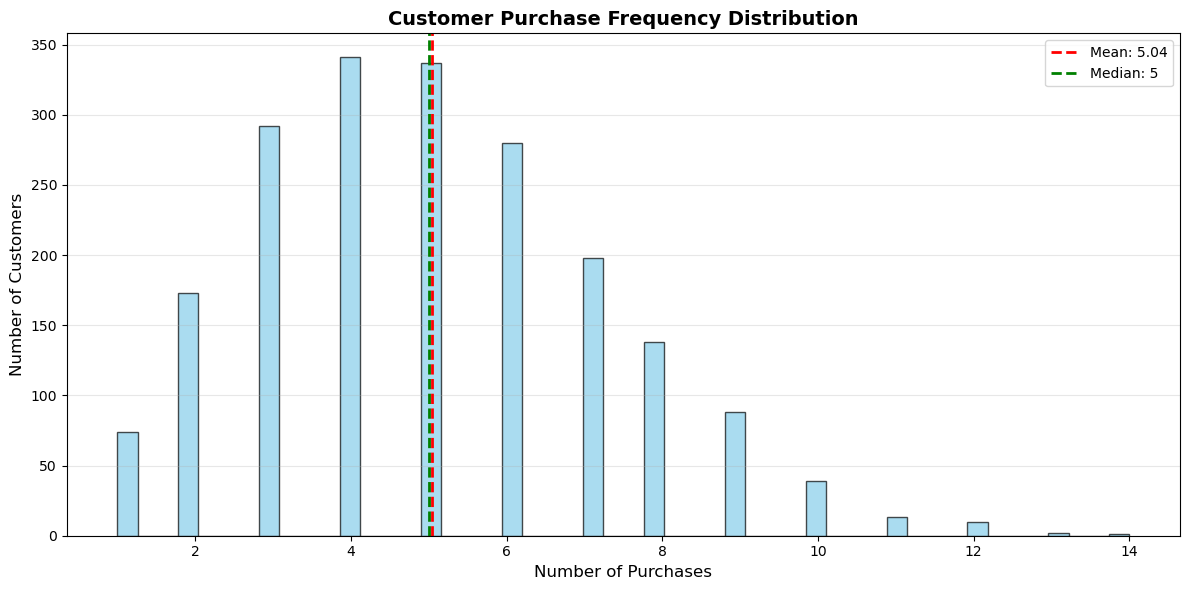


 Top 10 Customers by Revenue:
Customer_ID
CUST1097    1706.776827
CUST1800    1636.436219
CUST1939    1618.691144
CUST1463    1581.229018
CUST1295    1572.574497
CUST0685    1552.585540
CUST0947    1509.431327
CUST1717    1491.505450
CUST1261    1488.475286
CUST1846    1478.577891
Name: Sales, dtype: float64
✓ Saved: 14_top_customers.html

 Customer Retention:
Repeat Customers: 1,912 (96.27%)
One-time Customers: 74 (3.73%)


In [8]:
# ============================================================================
# 6. CUSTOMER BEHAVIOR ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("CUSTOMER BEHAVIOR ANALYSIS")
print("="*80)

# 6.1 Customer Purchase Frequency
if 'Customer_ID' in df.columns:
    print("\n Customer Purchase Frequency:")
    customer_frequency = df.groupby('Customer_ID').size().reset_index(name='Purchase_Count')
    
    print(f"Total Unique Customers: {len(customer_frequency):,}")
    print(f"Average Purchases per Customer: {customer_frequency['Purchase_Count'].mean():.2f}")
    print(f"Median Purchases per Customer: {customer_frequency['Purchase_Count'].median():.0f}")
    
    # Distribution
    plt.figure(figsize=(12, 6))
    plt.hist(customer_frequency['Purchase_Count'], bins=50, edgecolor='black', 
             alpha=0.7, color='skyblue')
    plt.title('Customer Purchase Frequency Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Purchases', fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.axvline(customer_frequency['Purchase_Count'].mean(), color='red', 
                linestyle='--', linewidth=2, label=f'Mean: {customer_frequency["Purchase_Count"].mean():.2f}')
    plt.axvline(customer_frequency['Purchase_Count'].median(), color='green', 
                linestyle='--', linewidth=2, label=f'Median: {customer_frequency["Purchase_Count"].median():.0f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/figures/13_customer_frequency.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: 13_customer_frequency.png")
    plt.show()

# 6.2 Top Customers by Revenue
if 'Customer_ID' in df.columns and 'Sales' in df.columns:
    print("\n Top 10 Customers by Revenue:")
    top_customers = df.groupby('Customer_ID')['Sales'].sum().sort_values(ascending=False).head(10)
    print(top_customers)
    
    # Visualization
    fig = px.bar(top_customers.reset_index(), 
                 x='Customer_ID', 
                 y='Sales',
                 title='Top 10 Customers by Total Revenue',
                 labels={'Sales': 'Total Revenue ($)', 'Customer_ID': 'Customer ID'},
                 color='Sales',
                 color_continuous_scale='reds')
    fig.write_html('outputs/figures/14_top_customers.html')
    print("✓ Saved: 14_top_customers.html")
# 6.3 Customer Retention (Repeat vs One-time)
if 'Is_Repeat_Customer' in df.columns:
    print("\n Customer Retention:")
    retention = df.groupby('Customer_ID')['Is_Repeat_Customer'].max()
    repeat_count = retention.sum()
    total_customers = len(retention)
    retention_rate = (repeat_count / total_customers) * 100
    
    print(f"Repeat Customers: {repeat_count:,} ({retention_rate:.2f}%)")
    print(f"One-time Customers: {total_customers - repeat_count:,} ({100 - retention_rate:.2f}%)")

In [9]:
# ============================================================================
# 7. PRODUCT PERFORMANCE ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("PRODUCT PERFORMANCE ANALYSIS")
print("="*80)

# 7.1 Top Selling Products
if 'Product_ID' in df.columns and 'Sales' in df.columns:
    print("\n Top 20 Products by Revenue:")
    product_performance = df.groupby('Product_ID').agg({
        'Sales': 'sum',
        'Quantity': 'sum',
        'Order_ID': 'count'
    }).sort_values('Sales', ascending=False).head(20)
    product_performance.columns = ['Total_Revenue', 'Total_Quantity', 'Order_Count']
    print(product_performance)
    
    # Dual axis chart
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=product_performance.index,
        y=product_performance['Total_Revenue'],
        name='Revenue',
        marker_color='indianred',
        yaxis='y'
      ))
    fig.add_trace(go.Scatter(
        x=product_performance.index,
        y=product_performance['Total_Quantity'],
        name='Quantity',
        mode='lines+markers',
        marker_color='lightsalmon',
        yaxis='y2'
    ))
    
    fig.update_layout(
        title='Top 20 Products: Revenue vs Quantity',
        xaxis=dict(title='Product ID', tickangle=45),
        yaxis=dict(title='Revenue ($)', side='left'),
        yaxis2=dict(title='Quantity Sold', overlaying='y', side='right'),
        hovermode='x unified',
        height=600
    )
    fig.write_html('outputs/figures/15_top_products.html')
    print("✓ Saved: 15_top_products.html")
    # 7.2 Category Performance Matrix
if 'Product_Category' in df.columns:
    print("\n Category Performance Matrix:")
    category_matrix = df.groupby('Product_Category').agg({
        'Sales': ['sum', 'mean'],
        'Order_ID': 'count',
        'Customer_ID': 'nunique'
    })
    category_matrix.columns = ['Total_Sales', 'Avg_Order_Value', 'Order_Count', 'Unique_Customers']
    category_matrix['Revenue_Share'] = (category_matrix['Total_Sales'] / category_matrix['Total_Sales'].sum() * 100).round(2)
    print(category_matrix.round(2))
    
    # Scatter plot
    fig = px.scatter(category_matrix.reset_index(), 
                     x='Order_Count', 
                     y='Avg_Order_Value',
                     size='Total_Sales', 
                     color='Product_Category',
                     title='Category Performance: Orders vs AOV (Size = Revenue)',
                     labels={'Order_Count': 'Number of Orders', 
                             'Avg_Order_Value': 'Average Order Value ($)'},
                     hover_data=['Total_Sales', 'Unique_Customers'])
    fig.write_html('outputs/figures/16_category_performance.html')
    print("✓ Saved: 16_category_performance.html")
    # 7.3 Pareto Analysis (80-20 Rule)
if 'Product_ID' in df.columns and 'Sales' in df.columns:
    print("\n Pareto Analysis (80-20 Rule):")
    product_sales = df.groupby('Product_ID')['Sales'].sum().sort_values(ascending=False)
    product_sales_cumsum = product_sales.cumsum() / product_sales.sum() * 100
    
    # Find top products contributing to 80% sales
    top_80_pct = (product_sales_cumsum <= 80).sum()
    pct_products = (top_80_pct / len(product_sales)) * 100
    
    print(f"Top {top_80_pct} products ({pct_products:.1f}%) generate 80% of revenue")
    print(f"Total products: {len(product_sales)}")


PRODUCT PERFORMANCE ANALYSIS

 Top 20 Products by Revenue:
            Total_Revenue  Total_Quantity  Order_Count
Product_ID                                            
PROD0442      4364.904924             160           32
PROD0260      3965.914047             153           29
PROD0145      3697.816857             145           30
PROD0385      3647.791839             177           31
PROD0340      3566.417039             163           33
PROD0045      3561.748514             137           30
PROD0433      3450.988764             153           28
PROD0044      3426.108501             157           26
PROD0070      3360.277493             130           26
PROD0378      3357.467981             148           28
PROD0367      3336.315252             146           29
PROD0075      3312.532965             123           26
PROD0301      3279.813089             153           26
PROD0058      3263.749044             155           30
PROD0222      3263.458088             132           26
PROD0

In [10]:
# ============================================================================
# 8. ADVANCED INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("ADVANCED INSIGHTS")
print("="*80)

# 8.1 Sales Distribution Analysis
if 'Sales' in df.columns:
    print("\n Sales Distribution:")
    print(f"Mean: ${df['Sales'].mean():.2f}")
    print(f"Median: ${df['Sales'].median():.2f}")
    print(f"Std Dev: ${df['Sales'].std():.2f}")
    print(f"Min: ${df['Sales'].min():.2f}")
    print(f"Max: ${df['Sales'].max():.2f}")
    print(f"\nPercentiles:")
    for p in [25, 50, 75, 90, 95, 99]:
        print(f"  {p}th: ${df['Sales'].quantile(p/100):.2f}")

# 8.2 Discount Impact Analysis
if 'Discount' in df.columns and 'Sales' in df.columns:
    print("\n Discount Impact on Sales:")
    discount_groups = pd.cut(df['Discount'], bins=[-0.01, 0, 0.1, 0.2, 1], 
                             labels=['No Discount', '1-10%', '11-20%', '20%+'])
    discount_analysis = df.groupby(discount_groups)['Sales'].agg(['count', 'mean', 'sum'])
    discount_analysis.columns = ['Order_Count', 'Avg_Order_Value', 'Total_Sales']
    print(discount_analysis)
    # 8.3 Delivery Performance
if 'Delivery_Days' in df.columns:
    print("\n Delivery Performance:")
    print(f"Average Delivery Time: {df['Delivery_Days'].mean():.1f} days")
    print(f"Median Delivery Time: {df['Delivery_Days'].median():.0f} days")
    
    if 'Delivery_Category' in df.columns:
        delivery_dist = df['Delivery_Category'].value_counts()
        print("\nDelivery Category Distribution:")
        print(delivery_dist)


ADVANCED INSIGHTS

 Sales Distribution:
Mean: $107.87
Median: $92.92
Std Dev: $64.55
Min: $10.35
Max: $275.33

Percentiles:
  25th: $58.33
  50th: $92.92
  75th: $145.13
  90th: $202.73
  95th: $246.45
  99th: $275.33

 Discount Impact on Sales:
             Order_Count  Avg_Order_Value    Total_Sales
Discount                                                
No Discount         4032       106.860334  430860.864843
1-10%               2027       106.394636  215661.927523
11-20%              3442       109.536013  377022.955799
20%+                 499       110.471405   55125.231311

 Delivery Performance:
Average Delivery Time: 1.0 days
Median Delivery Time: 1 days

Delivery Category Distribution:
Delivery_Category
Same/Next Day    10000
Name: count, dtype: int64


In [11]:
# ============================================================================
# 9. KEY FINDINGS SUMMARY
# ============================================================================

print("\n" + "="*80)
print("KEY FINDINGS FROM EDA")
print("="*80)

findings = []

# Finding 1: Top category
if 'Product_Category' in df.columns:
    top_category = df.groupby('Product_Category')['Sales'].sum().idxmax()
    top_category_pct = (df.groupby('Product_Category')['Sales'].sum().max() / df['Sales'].sum() * 100)
    findings.append(f"1. {top_category} is the top category, generating {top_category_pct:.1f}% of total revenue")

# Finding 2: Customer retention
if 'Customer_ID' in df.columns:
    customer_freq = df.groupby('Customer_ID').size()
    repeat_customers = (customer_freq > 1).sum()
    total_customers = len(customer_freq)
    retention_rate = (repeat_customers / total_customers * 100)
    findings.append(f"2. Customer retention rate is {retention_rate:.1f}% ({repeat_customers:,} of {total_customers:,} customers)")

# Finding 3: Seasonality
if 'Quarter' in df.columns:
    quarterly_sales = df.groupby('Quarter')['Sales'].sum()
    peak_quarter = quarterly_sales.idxmax()
    peak_pct = (quarterly_sales.max() / quarterly_sales.sum() * 100)
    findings.append(f"3. Q{peak_quarter} is the peak quarter, accounting for {peak_pct:.1f}% of annual sales")
    # Finding 4: Weekend effect
if 'Is_Weekend' in df.columns:
    weekend_avg = df[df['Is_Weekend'] == 1]['Sales'].mean()
    weekday_avg = df[df['Is_Weekend'] == 0]['Sales'].mean()
    lift = ((weekend_avg / weekday_avg - 1) * 100)
    findings.append(f"4. Weekend sales are {abs(lift):.1f}% {'higher' if lift > 0 else 'lower'} than weekday sales")

# Finding 5: Product concentration
if 'Product_ID' in df.columns:
    product_sales = df.groupby('Product_ID')['Sales'].sum().sort_values(ascending=False)
    top_20_pct = int(len(product_sales) * 0.2)
    top_20_revenue_pct = (product_sales.head(top_20_pct).sum() / product_sales.sum() * 100)
    findings.append(f"5. Top 20% of products generate {top_20_revenue_pct:.1f}% of revenue (Pareto principle confirmed)")

for finding in findings:
    print(f"\n{finding}")

# Save findings
findings_text = "\n".join(findings)
with open('outputs/reports/03_eda_key_findings.txt', 'w') as f:
    f.write("KEY FINDINGS FROM EXPLORATORY DATA ANALYSIS\n")
    f.write("="*80 + "\n\n")
    f.write(findings_text)
    f.write(f"\n\nGenerated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print("\n✓ Key findings saved to: outputs/reports/03_eda_key_findings.txt")

print("\n" + "="*80)
print("Part2 COMPLETED SUCCESSFULLY!")
print("="*80)
print("\n Next Step: Part4 - Customer Segmentation & Advanced Analytics")
print("="*80)


KEY FINDINGS FROM EDA

1. Electronics is the top category, generating 30.4% of total revenue

2. Customer retention rate is 96.3% (1,912 of 1,986 customers)

3. Q1 is the peak quarter, accounting for 34.2% of annual sales

4. Weekend sales are 0.9% higher than weekday sales

5. Top 20% of products generate 27.3% of revenue (Pareto principle confirmed)

✓ Key findings saved to: outputs/reports/03_eda_key_findings.txt

Part2 COMPLETED SUCCESSFULLY!

 Next Step: Part4 - Customer Segmentation & Advanced Analytics
